In [1]:
# This example follows the steps of the main demonstration while using a large number of iterations to probe a stickier boundary region
# The main domain loop is mostly used to construct an enclosing shell around the stable region of interest
# This shell is then propagated using forward and backward iterations to illustrate the construction of the finite-time transport skeleton
# The domain obtained from forward iterations grows along the unstable hyperbolic manifolds, whereas the domain obtained from backward iterations grows along the stable hyperbolic manifolds

In [2]:
# Import 

from tqdm import tqdm

import numpy as np
from numpy.typing import NDArray
from numba import njit

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

from domain.scan import iterate
from domain.scan import count
from domain.scan import scan
from domain.scan import orbit

from domain.da import da
from domain.da import refine

from domain.volume import rays
from domain.volume import directions
from domain.volume import volume
from domain.volume import mean

from domain.sample import sample
from domain.sample import mask
from domain.sample import filter
from domain.sample import select
from domain.domain import Domain

from domain import Configuration
from domain import Result
from domain import compute

In [3]:
# Set global parameters

dimension = 4                            # -- phase-space dimension
dl = 0.01                                # -- domain cell side length
dr = dl*dimension**0.5                   # -- radial step size
lb = np.array([-1.5, -1.5, -1.5, -1.5])  # -- domain lower bounds for (qx, qy, px, py)
ub = np.array([+1.5, +1.5, +1.5, +1.5])  # -- domain upper bounds for (qx, qy, px, py)
size = 131072                            # -- total number of iterations
ndirections = 8                          # -- number of initial random directions
nsamples = 512                           # -- number of random marked cells selected from the current marked cells
npoints = 8                              # -- number of random points to generate for each selected cell
nrounds = 128                            # -- maximum number of expansion rounds to perform
nepochs = 32                             # -- number of domain computations (MC over initial directions and expansion)
center = np.array([0., 0., 0., 0])       # -- domain center
cut = 1.0                                # -- selection cut radius
threshold = 5.0                          # -- threshold radius (an initial condition with larger radius is considered lost)
termination = 0.99                       # -- termination parameter (fraction of rays hitting marked domain cells)
scale = 3.0                              # -- perturbation scaling factor for new sample generation
bins_plane = 16                          # -- number of bins for the mixing coordinate
bins_phase = 32                          # -- number of bins for the in-plane phases
phase_threshold = 1.0E-3                 # -- phase threshold used in weighted selection
alpha_plane = 1.0                        # -- plane weight factor
alpha_phase = 0.5                        # -- phase weight factor
boost = 0.5                              # -- weight boost near the edges
delta = 1.0                              # -- inverse-density score regularization
uniform = 0.05                           # -- fraction of uniform sampling to use
power = 1.0                              # -- score power
uniform = 0.05                           # -- fraction of uniform sampling

In [4]:
# Define forward and inverse Henon maps

@njit
def forward4d(
    x:NDArray[np.float64], 
    parameters:NDArray[np.float64]
) -> NDArray[np.float64]:
    """
    Forward 4D Henon symplectic mapping

    Parameters
    ----------
    x: NDArray[np.float64], (dimension, )
        initial condition
    parameters: NDArray[np.float64]
        mapping parameters

    Returns
    -------
    NDArray[np.float64]

    """
    qx, qy, px, py = x
    cx, sx, cy, sy, mu = parameters
    Qx = cx*qx + sx*(px + qx**2 - qy**2 + mu*(qx**3 - 3*qx*qy**2))
    Qy = cy*qy + sy*(py - 2*qx*qy + mu*(-3*qx**2*qy + qy**3))
    Px = cx*(px + qx**2 - qy**2 + mu*(qx**3 - 3*qx*qy**2)) - sx*qx
    Py = cy*(py - 2*qx*qy + mu*(-3*qx**2*qy + qy**3)) - sy*qy
    return np.array([Qx, Qy, Px, Py])


@njit
def inverse4d(
    x: NDArray[np.float64], 
    parameters: NDArray[np.float64]
) -> NDArray[np.float64]:
    """
    Accelerator mapping (Henon) symplectic mapping (inverse)

    Parameters
    ----------
    x: NDArray[np.float64], (dimension, )
        initial condition
    parameters: NDArray[np.float64]
        mapping parameters

    Returns
    -------
    NDArray[np.float64]

    """
    qx, qy, px, py = x
    cx, sx, cy, sy, mu = parameters
    Qx = cx*qx - sx*px
    Qy = cy*qy - sy*py
    Px = cx*px + sx*qx - Qx**2 + Qy**2 - mu*(Qx**3 - 3*Qx*Qy**2)
    Py = cy*py + sy*qy + 2*Qx*Qy - mu*(-3*Qx**2*Qy + Qy**3)
    return np.array([Qx, Qy, Px, Py])

In [5]:
# Set mapping parameters

nux, nuy = 0.28, 0.31
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])

In [6]:
# Test mapping

print(forward4d(center, knobs))

[ 0.  0. -0. -0.]


In [7]:
# Define the objective function

objective = iterate(size, threshold, forward4d)

print(objective(center + 0.0*threshold, knobs))
print(objective(center + 1.0*threshold, knobs))

True
False


In [8]:
# Define the complexity function (number of stable iterations)

complexity_forward = count(size, threshold, forward4d)
complexity_inverse = count(size, threshold, inverse4d)

print(complexity_forward(center + 0.0*threshold, knobs))
print(complexity_forward(center + 1.0*threshold, knobs))

131072
0


In [9]:
%%time

# Standard DA computation with complexity evaluation

# 1. Generate a structured grid of directions and the corresponding volume-computation factors
# 2. Compute the last unstable radius along each ray and the corresponding phase-space point
# 3. Compute the total number of evaluations for stable initial conditions
# 4. Compute the number of iterations/invocations for each unstable phase-space point and the corresponding total over all rays
# 5. Compute the phase-space volume using the last unstable, last stable, and midpoint radii
# 6. Refine the DA boundary using several bisection steps
# 7. Report the results

# Set the structured ray grid

# dimension  : 2*k
# directions : (n**(k - 1) * m**dimension, 2*k)
# factors    : (n**(k - 1), )

# qx = r cos(psi) cos(phi_x)
# qy = r sin(psi) cos(phi_y)
# px = r cos(psi) sin(phi_x)
# py = r sin(psi) sin(phi_y)

n, m = 64, 64
ds, factors = rays(dimension, n, m)
print(ds.shape)
print()

# DA computation (first unstable radius for each ray)

rb, xb = da(dimension, dr, threshold, center, ds, objective, knobs, unstable=True) 
print(rb.shape)
print(xb.shape)
print()

# Cost (stable points evaluation) 

cs = int(size*np.sum((rb/dr) - 1))

# Cost (unstable points evaluation)

table = np.zeros(len(ds), dtype=np.int64)
scan(xb, table, complexity_forward, knobs)
cu = int(np.sum(1 + table))

# Cost summary
# Note, the bisection step is not included in the cost, since midpoint estimation can be used instead

print(cs)
print(cu)
print(ct := cs + cu)
print(100*cs/ct, 100*cu/ct)
print()

# Compute effective radius (stable, midpoint, unstable)

rl, _ = volume(dimension, n, m, rb - 1.0*dr, factors)
rh, _ = volume(dimension, n, m, rb - 0.5*dr, factors)
ru, _ = volume(dimension, n, m, rb - 0.0*dr, factors)

# Refine DA (bisection)

rb_refine, xb_refine = refine(dimension, dr, threshold, center, ds, 16, rb - dr, objective, knobs)

# Compute effective radius

rr, _ = volume(dimension, n, m, rb_refine, factors)

# DA summary
# The midpoint estimate is close to the refined value
# The geometric mean over all radii gives a better estimate than the arithmetic mean; see the radius distributions below

print(rl)
print(rh)
print(ru)
print()

print(rr)
print(np.mean(rb_refine))
print(np.mean(rb_refine**dimension)**(1/dimension))
print()

(262144, 4)

(262144,)
(262144, 4)

678036242432
4494478882
682530721314
99.34149793677459 0.6585020632254154

0.406750126814751
0.41625737155830583
0.4257874485798856

0.4164603910636772
0.40500042121391744
0.42271300005147294

CPU times: user 17h 21min 54s, sys: 25.8 s, total: 17h 22min 20s
Wall time: 42min 17s


In [10]:
%%time

# Random-ray DA computation with complexity evaluation

# 1. Select random rays and iterate along them
# 2. Compute the geometric mean over all final stable radii
# 3. Perform MC over the initial ray sample
# 4. Compute the central value and spread estimates and compare with structured grid ray based DA

# Total number of rays

print(64*2**10)
print()

# Computations loop

rs = []
estimates = []
count = 0
for _ in tqdm(range(64)):
    ds = directions(dimension, 2**10)
    rb, xb = da(dimension, dr, threshold, center, ds, objective, knobs, unstable=True) 
    rb, xb = refine(dimension, dr, threshold, center, ds, 16, rb - dr, objective, knobs)
    estimate = mean(dimension, rb)
    estimates.append(estimate)
    rs.append(rb)
    count += int(size*np.sum((rb/dr) - 1))

# Compare estimated effective radius
# Random rays also provide provide estimation uncertanty

print(rr)
print( mean(dimension, rb_refine))
print(np.mean(estimates), np.std(estimates))
print(100*np.abs(rr - np.mean(estimates))/rr)
print()

# Compare costs (including only stable evaluations; unstable evaluations and bisection refinements are excluded)

print(cs)
print(count)
print(cs/count)
print()

65536



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [11:02<00:00, 10.35s/it]

0.4164603910636772
0.4225678075269994
0.4157592790712762 0.003007480622424297
0.16835022188072288

678036242432
162202072034
4.180194703615583

CPU times: user 4h 7min 44s, sys: 6.25 s, total: 4h 7min 50s
Wall time: 11min 2s


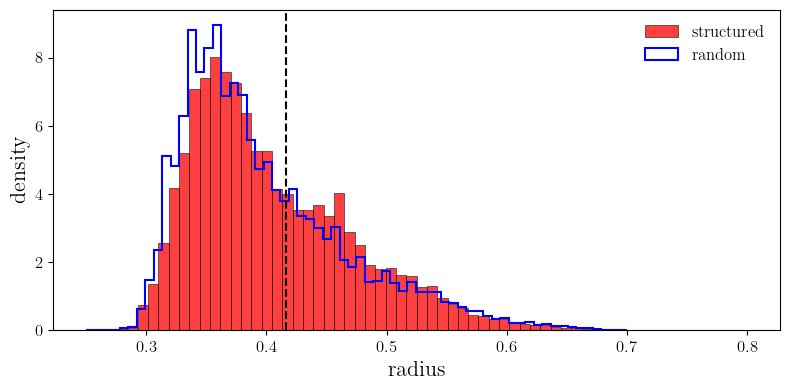

In [11]:
# Compare distibutions of final stable radii explored using fine structured grid and MC over random rays

plt.figure(figsize=(8, 4))

plt.hist(rb_refine, 64, range=(0.25, 0.8), density=True, color='red', alpha=0.75, edgecolor='black', linewidth=0.5, label=r"structured")
plt.hist(np.asarray(rs).flatten(), 64 , range=(0.25, 0.7), density=True, histtype='step', linewidth=1.5, color='blue', label=r"random")
plt.axvline(rr, color='black', linestyle='dashed')
plt.xlabel(r"$\mathrm{radius}$", fontsize=16)
plt.ylabel(r"$\mathrm{density}$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.show()

In [12]:
# The domain loop

configuration = Configuration(
    lb=lb,
    ub=ub,
    dl=dl,
    size=size,
    ndirections=ndirections,
    nsamples=nsamples,
    npoints=npoints,
    nrounds=nrounds,
    nepochs=nepochs,
    center=center,
    cut=cut,
    threshold=threshold,
    termination=termination,
    scale=scale,
    lds=[1.0],
    bins_plane=bins_plane,
    bins_phase=bins_phase,
    phase_threshold=phase_threshold,
    alpha_plane=alpha_plane,
    alpha_phase=alpha_phase,
    boost=boost,
    delta=delta
)

result = compute(
    configuration=configuration,
    parameters=knobs,
    pairs=[(64, 64)],
    mapping=forward4d,
    objective=objective,
    cost=complexity_forward,
    full=True,
    complexity=True,
    verbose=True
)

0

(8, 4)
(1048576, 4)
(404626, 4)

(336369, 8208541201)

01       144328        86347        32.94      4429067 0.3774146857262632
02       150868        75457        28.78      5126276 0.37796474918034134
03       169856        43393        16.55      5896030 0.3893812181566366
04       174891        34247        13.06      6564548 0.39140966799190624
05       176185        31953        12.19      6825986 0.3922168090973322
06       182444        19875         7.58      7091477 0.395131570938242
07       185155        15157         5.78      7283681 0.3974563568546747
08       186002        13486         5.14      7420959 0.3978650542149528
09       186557        11804         4.50      7553176 0.39814289665605385
10       186896        10415         3.97      7659778 0.3980912480501613
11       187046         9956         3.80      7753774 0.39801764114468396
12       188087         8574         3.27      7875835 0.39968450098316016
13       188948         6676         2.55      804

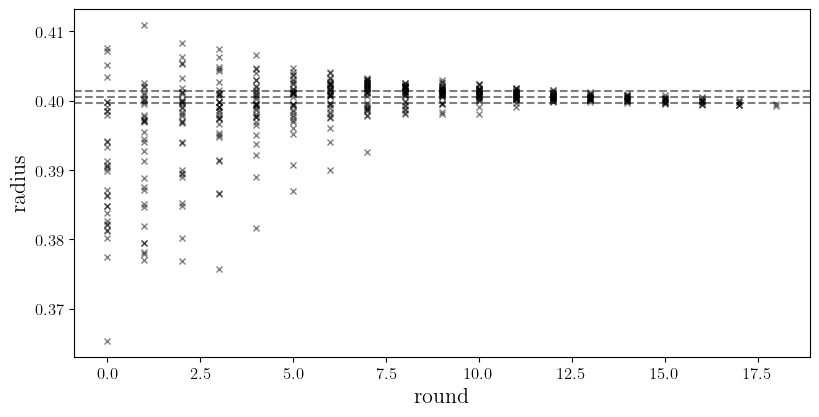

(0.401, 0.001)


In [13]:
# Examine running estimated effective radius convergence over all MC realizations

plt.figure(figsize=(8, 4))

for rs in result.rads:
    plt.errorbar(range(len(rs)), rs, color='black', fmt='x', ms=4, alpha=0.5)

rs = np.asarray([r for *_, r in result.rads])
r_center = np.mean(rs)
r_spread = np.std(rs)

plt.axhline(r_center - r_spread, linestyle='dashed', color='black', alpha=0.5)
plt.axhline(r_center, linestyle='dashed', color='black', alpha=0.5)
plt.axhline(r_center + r_spread, linestyle='dashed', color='black', alpha=0.5)

plt.tight_layout()
plt.xlabel(r"round", fontsize=16)
plt.ylabel(r"radius", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

print(f'({r_center:.3f}, {r_spread:.3f})')

In [14]:
# Extract radius data from domain

n, m = 64, 64
rads = []
rads_all = []
ds, factors = rays(dimension, n, m)
for cell in result.cells:
    pass
    keys, rh, _ = cell.boundary(n, m, center, ds)
    rg = mean(dimension, rh[keys != -1])
    rads.append(rg)
    rads_all.append(rh)
rads_all = np.array(rads_all)
rads_all = np.hstack(rads_all)

rs = np.asarray(rads)
r_center = np.mean(rs)
r_spread = np.std(rs)

print(f'({r_center:.3f}, {r_spread:.3f})')

(0.401, 0.001)


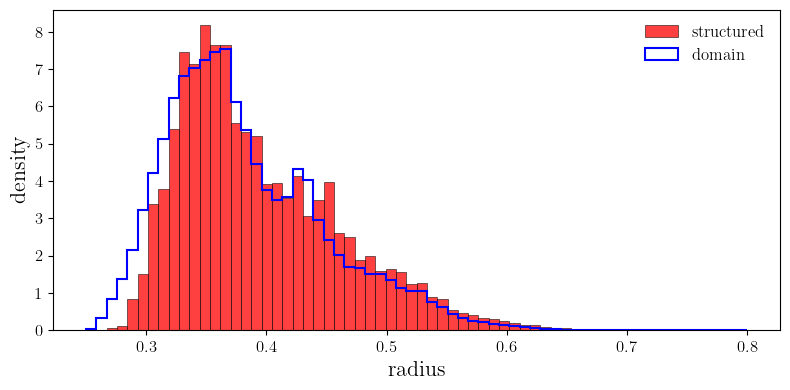

In [15]:
# Compare the distributions of final stable radii obtained using a fine structured grid and domain construction
# Since the radii in the domain represent unstable initial conditions, the structured grid results are shifted

plt.figure(figsize=(8, 4))

plt.hist(rb_refine - dr/2, 64, range=(0.25, 0.8), density=True, color='red', alpha=0.75, edgecolor='black', linewidth=0.5, label=r"structured")
plt.hist(rads_all, 64 , range=(0.25, 0.8), density=True, histtype='step', linewidth=1.5, color='blue', label=r"domain")

plt.xlabel(r"$\mathrm{radius}$", fontsize=16)
plt.ylabel(r"$\mathrm{density}$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.show()

In [16]:
# Process convergence data

table = []
for data in zip(result.data):
    data, *_ = data
    missed, hit, total = zip(*data)
    total, *_ = total
    missed = 100*np.array(missed)/total
    hit = 100*np.array(hit)/total
    table.append([missed, hit])
missed, hit = zip(*table)

In [17]:
# Number of rounds to reach 95% coverage

np.median(np.asarray([*map(len, missed)]))

np.float64(14.0)

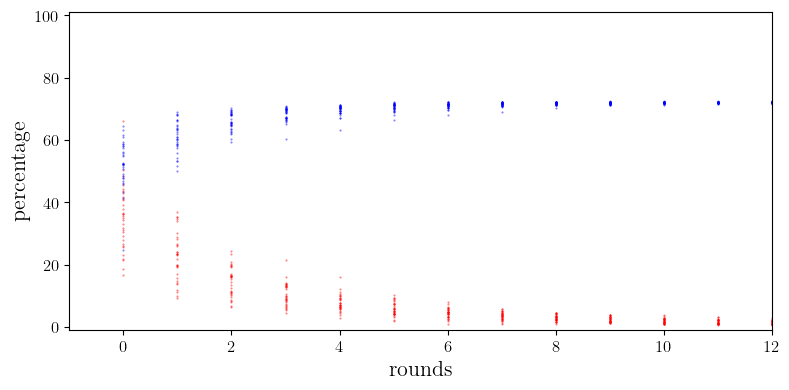

In [18]:
# Convergence

plt.figure(figsize=(8, 4))

for x in missed:
    plt.errorbar(range(len(x)), x, color='red', fmt='.', ms=1, alpha=0.5)

plt.tight_layout()
plt.xlabel(r"rounds", fontsize=16)
plt.ylabel(r"missed %", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-1, 101)
plt.ylim(-1, 101)

for x in hit:
    plt.errorbar(range(len(x)), x, color='blue', fmt='.', ms=1, alpha=0.5)

plt.xlabel(r"rounds", fontsize=16)
plt.ylabel(r"percentage %", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-1, 12)
plt.ylim(-1, 101)
plt.tight_layout()
plt.show()

In [19]:
# Compare cost (average expected evaluation cost without MC)
# With MC this cost should be multiplied by number of MC rounds

data = np.array([cs + cs + np.sum(array) for cs, cs, array in result.costs])

print(f'{np.log10(ct):>6.2f}')
print(f'{np.log10(np.mean(data)):>6.2f}')

 11.83
  9.76


In [20]:
# Set final accumulated domain shell

n, m = 64, 64
ds, factors = rays(dimension, n, m)

keys, *_ = result.container.boundary(n, m, center, ds)
flag = np.sum(keys == -1)
print(flag)

shell = Domain(lb, ub, dl)
shell.insert(keys[keys!=-1])
print(shell.size)

0
188416


In [21]:
# Grow the domain (forward)

domain_forward = Domain(lb, ub, dl)
domain_forward.insert(shell.keys)

orbits = np.empty((nsamples*npoints, size, dimension), dtype=np.float64)
for epoch in range(64):
    indices = np.random.choice(domain_forward.list, nsamples)
    centers = domain_forward.transform(indices)
    initial = sample(npoints, scale*dl, centers)
    scan(initial, orbits, orbit(size, threshold, forward4d), knobs)
    points = orbits[mask(orbits, threshold)].reshape(-1, dimension)
    points = filter(points, threshold)
    domain_forward.update(points)
    print(f'{epoch + 1:02d}', f'{domain_forward.size:12d}')
    if domain_forward.size > 64_000_000:
        break

01      4840161
02      6324653
03      6924488
04      7260052
05      7509244
06      7759296
07      8009214
08      8251176
09      8567390
10      8785444
11      8957519
12      9132021
13      9275832
14      9426047
15      9572858
16      9701860
17      9823676
18      9936691
19     10053873
20     10171533
21     10276826
22     10401630
23     10505164
24     10594915
25     10684991
26     10772933
27     10863393
28     10950148
29     11030654
30     11112121
31     11192384
32     11268446
33     11359209
34     11449233
35     11522776
36     11595814
37     11672240
38     11754157
39     11822000
40     11886623
41     11953439
42     12012868
43     12081139
44     12145977
45     12210009
46     12273560
47     12341653
48     12408940
49     12474239
50     12532637
51     12593948
52     12655727
53     12714657
54     12773703
55     12834722
56     12892213
57     12946513
58     13002268
59     13059011
60     13110181
61     13167960
62     13221587
63     1

In [22]:
# Grow the domain (inverse)

domain_inverse = Domain(lb, ub, dl)
domain_inverse.insert(shell.keys)

orbits = np.empty((nsamples*npoints, size, dimension), dtype=np.float64)
for epoch in range(64):
    indices = np.random.choice(domain_inverse.list, nsamples)
    centers = domain_inverse.transform(indices)
    initial = sample(npoints, scale*dl, centers)
    scan(initial, orbits, orbit(size, threshold, inverse4d), knobs)
    points = orbits[mask(orbits, threshold)].reshape(-1, dimension)
    points = filter(points, threshold)
    domain_inverse.update(points)
    print(f'{epoch + 1:02d}', f'{domain_inverse.size:12d}')
    if domain_inverse.size > 64_000_000:
        break

01      4548055
02      6164785
03      6856696
04      7208974
05      7490877
06      7689595
07      7864711
08      8022000
09      8177090
10      8305133
11      8428767
12      8551642
13      8675161
14      8780987
15      8877809
16      8966819
17      9078280
18      9190844
19      9303160
20      9476289
21      9674332
22      9872544
23     10011681
24     10136833
25     10274933
26     10389436
27     10490143
28     10595319
29     10697060
30     10806384
31     10902336
32     10989591
33     11078501
34     11161255
35     11242303
36     11319182
37     11396524
38     11482729
39     11553049
40     11634514
41     11708587
42     11792397
43     11863672
44     11935683
45     12006168
46     12079621
47     12141504
48     12220438
49     12285865
50     12347372
51     12413451
52     12474086
53     12537682
54     12598829
55     12654157
56     12715454
57     12771319
58     12830044
59     12890282
60     12948427
61     13007461
62     13060993
63     1

In [23]:
# Define forward and inverse domain plane masks (projected)

epsilon = 1.0E-6
width = 1

Qx_forward, Qy_forward, Px_forward, Py_forward = domain_forward.construct.T
mqx_forward = np.abs(Qx_forward) < width*dl + epsilon
mqy_forward = np.abs(Qy_forward) < width*dl + epsilon
mpx_forward = np.abs(Px_forward) < width*dl + epsilon
mpy_forward = np.abs(Py_forward) < width*dl + epsilon

Qx_inverse, Qy_inverse, Px_inverse, Py_inverse = domain_inverse.construct.T
mqx_inverse = np.abs(Qx_inverse) < width*dl + epsilon
mqy_inverse = np.abs(Qy_inverse) < width*dl + epsilon
mpx_inverse = np.abs(Px_inverse) < width*dl + epsilon
mpy_inverse = np.abs(Py_inverse) < width*dl + epsilon

In [24]:
# qx-qy

In [25]:
n = 1000
qx = np.linspace(-1.5, 1.5, n)
qy = np.linspace(-1.5, 1.5, n)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

mask_qxqy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxqy, complexity_forward, knobs)

mask_qxqy_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxqy_inverse, complexity_inverse, knobs)

ds = directions(dimension, 256, random=False, ij=(0, 1), omega_min=0.0, omega_max=2*np.pi)
rs, xs = da(dimension, dr, threshold, center, ds, objective, knobs)
qxa, qya, pxa, pya = xs.T

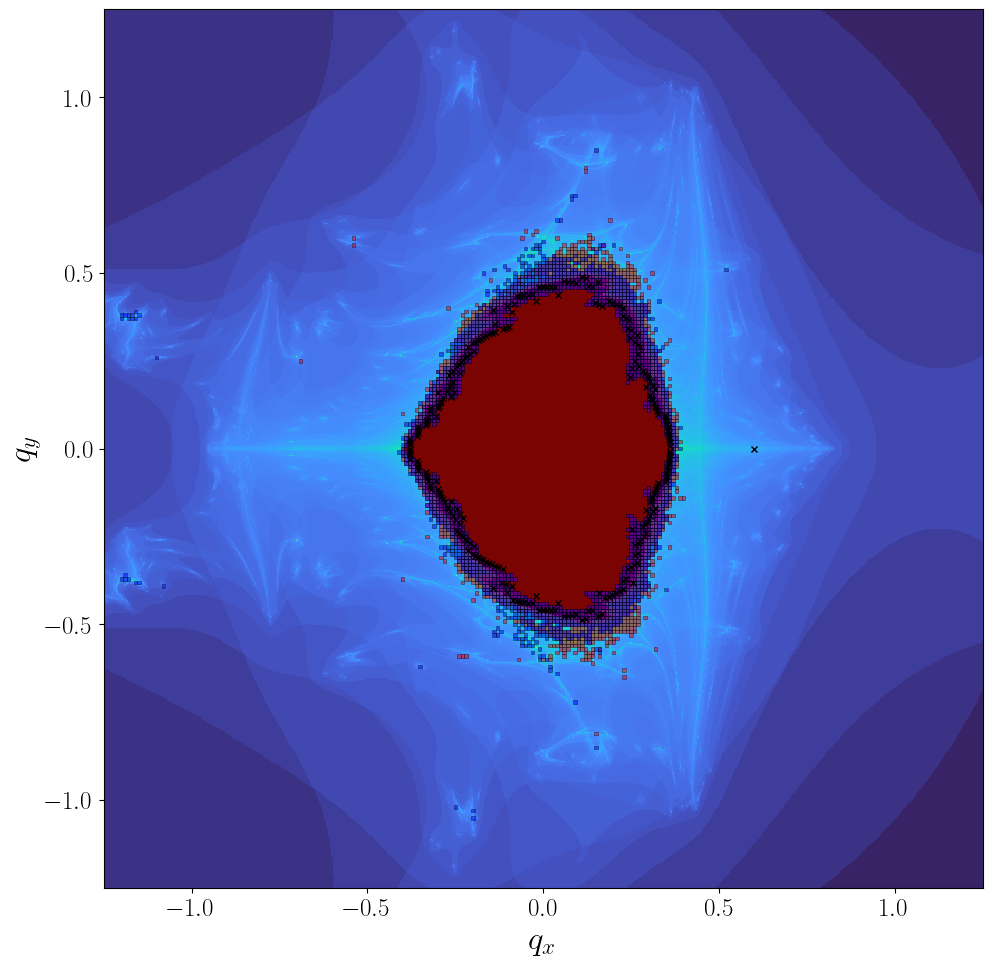

In [26]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_qxqy + mask_qxqy_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qx_forward[mpx_forward*mpy_forward], Qy_forward[mpx_forward*mpy_forward]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qx_inverse[mpx_inverse*mpy_inverse], Qy_inverse[mpx_inverse*mpy_inverse]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
ax.errorbar(qxa, qya, color='black', fmt=' ', marker='x', ms=4, zorder=2)
plt.xlabel('qx')
plt.ylabel('qy')
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$q_x$", fontsize=24)
plt.ylabel(r"$q_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [27]:
# qx-px

In [28]:
n = 1000
qx = np.linspace(-1.5, 1.5, n)
px = np.linspace(-1.5, 1.5, n)
qxpx = np.stack(np.meshgrid(qx, px, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qypy = np.full_like(qxpx, 0.0)
qx, px = qxpx.T
qy, py = qypy.T
xs = np.stack([qx, qy, px, py]).T

mask_qxpx = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxpx, complexity_forward, knobs)

mask_qxpx_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxpx_inverse, complexity_inverse, knobs)

ds = directions(dimension, 256, random=False, ij=(0, 2), omega_min=0.0, omega_max=2*np.pi)
rs, xs = da(dimension, dr, threshold, center, ds, objective, knobs)
qxb, qyb, pxb, pyb = xs.T

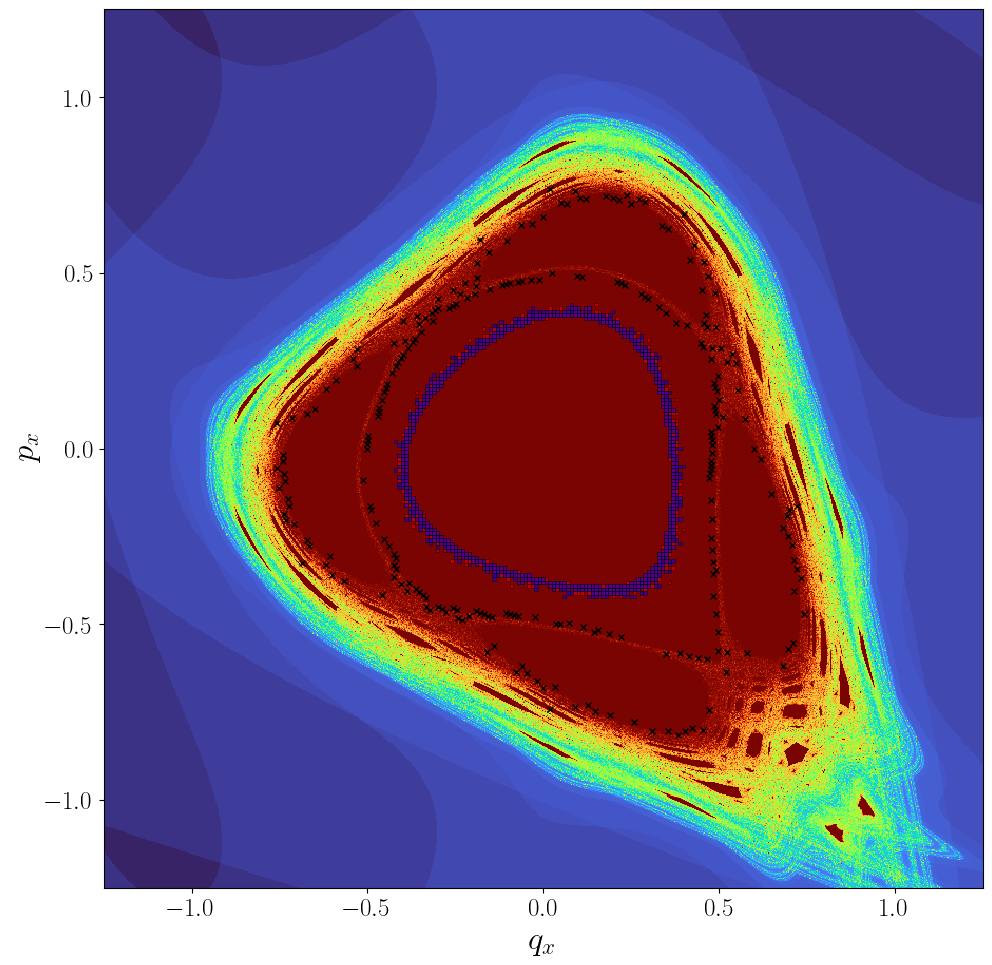

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_qxpx + mask_qxpx_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qx_forward[mqy_forward*mpy_forward], Px_forward[mqy_forward*mpy_forward]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qx_inverse[mqy_inverse*mpy_inverse], Px_inverse[mqy_inverse*mpy_inverse]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
ax.errorbar(qxb, pxb, color='black', fmt=' ', marker='x', ms=4, zorder=2)
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$q_x$", fontsize=24)
plt.ylabel(r"$p_x$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [30]:
# qy-py

In [31]:
n = 1000
qy = np.linspace(-1.5, 1.5, n)
py = np.linspace(-1.5, 1.5, n)
qypy = np.stack(np.meshgrid(qy, py, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qxpx = np.full_like(qypy, 0.0)
qy, py = qypy.T
qx, px = qxpx.T
xs = np.stack([qx, qy, px, py]).T

mask_qypy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qypy, complexity_forward, knobs)

mask_qypy_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qypy_inverse, complexity_inverse, knobs)

ds = directions(dimension, 256, random=False, ij=(1, 3), omega_min=0.0, omega_max=2*np.pi)
rs, xs = da(dimension, dr, threshold, center, ds, objective, knobs)
qxc, qyc, pxc, pyc = xs.T

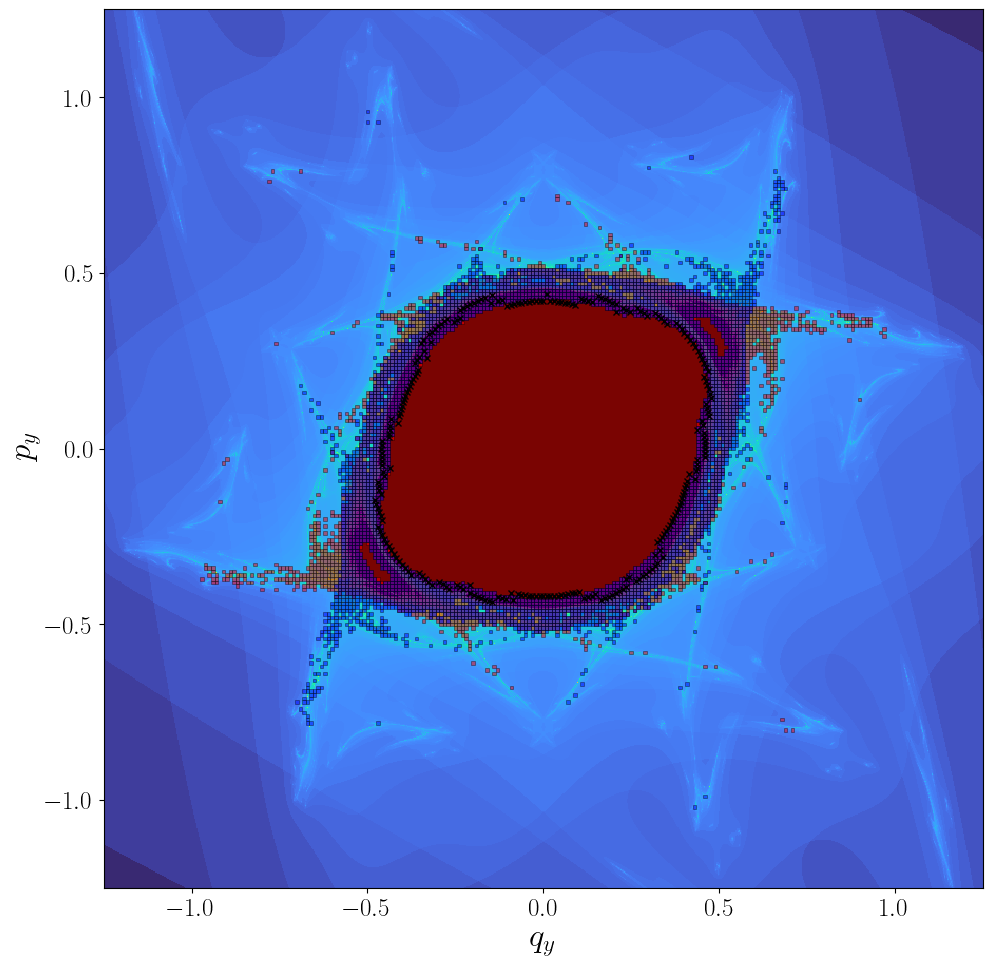

In [32]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_qypy + mask_qypy_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qy_forward[mqx_forward*mpx_forward], Py_forward[mqx_forward*mpx_forward]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qy_inverse[mqx_inverse*mpx_inverse], Py_inverse[mqx_inverse*mpx_inverse]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
ax.errorbar(qyc, pyc, color='black', fmt=' ', marker='x', ms=4, zorder=2)
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$q_y$", fontsize=24)
plt.ylabel(r"$p_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [33]:
# px-py

In [34]:
n = 1000
px = np.linspace(-1.5, 1.5, n)
py = np.linspace(-1.5, 1.5, n)
pxpy = np.stack(np.meshgrid(px, py, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qxqy = np.full_like(pxpy, 0.0)
px, py = pxpy.T
qx, qy = qxqy.T
xs = np.stack([qx, qy, px, py]).T

mask_pxpy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_pxpy, complexity_forward, knobs)

mask_pxpy_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_pxpy_inverse, complexity_inverse, knobs)

ds = directions(dimension, 256, random=False, ij=(2, 3), omega_min=0.0, omega_max=2*np.pi)
rs, xs = da(dimension, dr, threshold, center, ds, objective, knobs)
qxd, qyd, pxd, pyd = xs.T

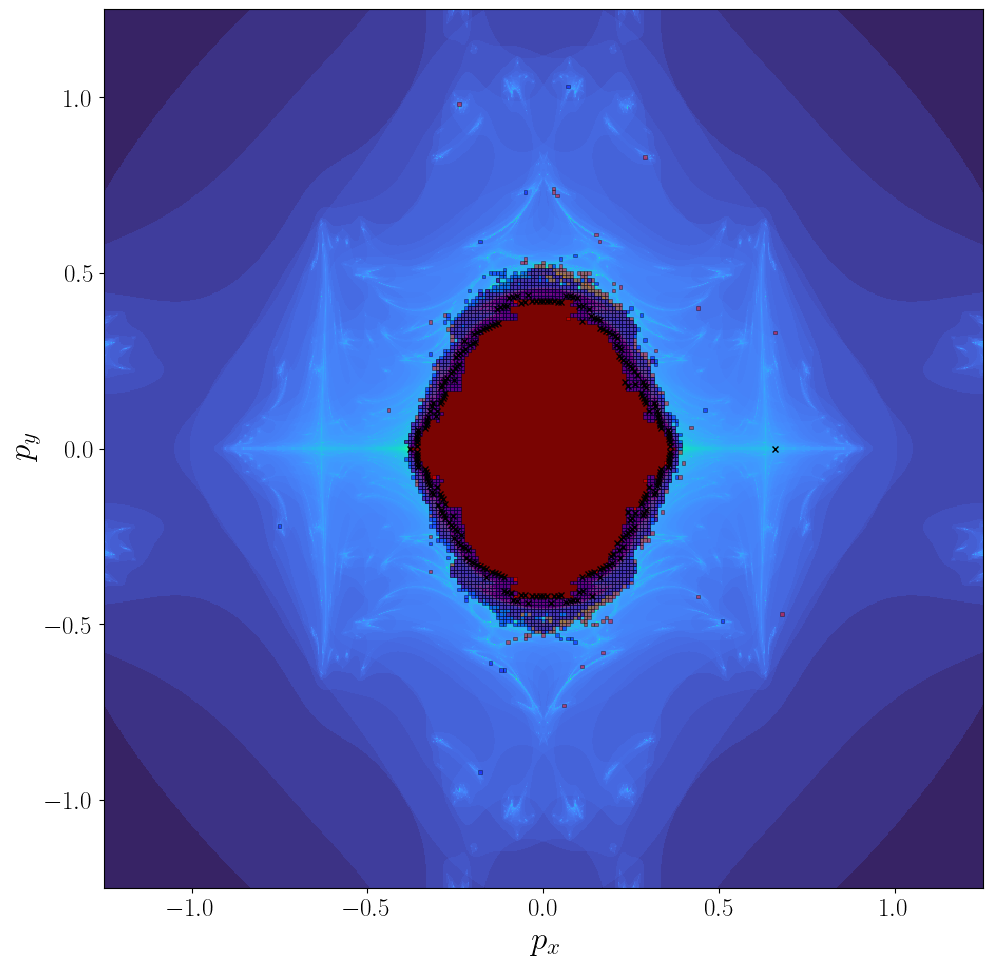

In [35]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_pxpy + mask_pxpy_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Px_forward[mqx_forward*mqy_forward], Py_forward[mqx_forward*mqy_forward]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Px_inverse[mqx_inverse*mqy_inverse], Py_inverse[mqx_inverse*mqy_inverse]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
ax.errorbar(pxd, pyd, color='black', fmt=' ', marker='x', ms=4, zorder=2)
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$p_x$", fontsize=24)
plt.ylabel(r"$p_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()